In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("BotnetFull.csv")

In [3]:
pip install keras-tuner --upgradeb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 3.7 MB/s eta 0:00:00


this is our best model till now , let me show the results

Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8926 - loss: 0.5609 - val_accuracy: 0.9747 - val_loss: 0.4257
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9802 - loss: 0.1765 - val_accuracy: 0.9747 - val_loss: 0.2956
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9779 - loss: 0.1395 - val_accuracy: 0.9747 - val_loss: 0.2092
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9812 - loss: 0.1263 - val_accuracy: 0.9747 - val_loss: 0.1547
Epoch 5/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9734 - loss: 0.1243 - val_accuracy: 0.9747 - val_loss: 0.1320
Epoch 6/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9828 - loss: 0.1069 - val_accuracy: 0.9783 - val_loss: 0.1197
Epoch 7/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9909 - loss: 0.0870 - val_accuracy: 0.9783 - val_loss: 0.1065
Epoch 8/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9924 - loss: 0.0760 - val_accuracy: 0.9783 - val_los

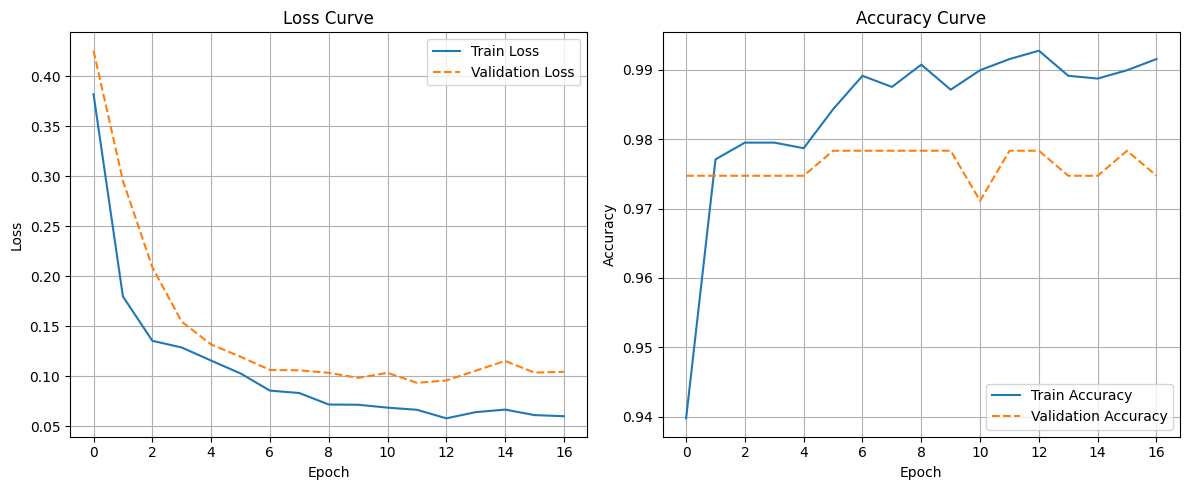

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,BatchNormalization,Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from tensorflow.keras.regularizers import l2

# Step 1: Load and clean the dataset
df = pd.read_csv("BotnetFull.csv")
df.columns = df.columns.str.replace('\n', '', regex=True).str.strip()

# Step 2: Split features and label (last column is label)
X = df.iloc[:, :-1].values  # First 455 columns = features
y = df.iloc[:, -1].values   # Last column = label (0 or 1)

# # Step 3: Normalize features
# scaler = StandardScaler()
# X = scaler.fit_transform(X)

# Step 4: Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 5: Define the MLP model
model4 = Sequential([
    Dense(454, input_shape=(455,),kernel_regularizer=l2(0.001), use_bias=False),  # Hidden layer
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.4),  # Dropout layer (50% dropout rate)
    Dense(1, activation='sigmoid',kernel_regularizer=l2(0.001))                      # Output layer
])

# Step 6: Compile the model4
optimizer = Adam(learning_rate=0.001)
model4.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Step 7: Add Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Step 8: Train the model4
history = model4.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Step 9: Evaluate on test set
test_loss, test_acc = model4.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Test Accuracy: {test_acc * 100:.2f}%")

# Step 10: Plot loss and accuracy curves
plt.figure(figsize=(12, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='--')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linestyle='--')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Step 11: Save the model4
# model2.save("botnet_original_arch_dropout.h5")
# print("✅ Model saved as 'botnet_mlp_model_keras.h5'")



now we will apply keras tuner to get the best optimizer for this model

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Activation, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt

def build_model(hp):
    model = Sequential()
    model.add(Dense(454, input_shape=(455,),kernel_regularizer=l2(0.001), use_bias=False))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.4))
    model.add(Dense(1, activation='sigmoid', kernel_regularizer=l2(0.001)))

    optimizer = hp.Choice('optimizer', values=['adam', 'sgd', 'rmsprop', 'adadelta', 'adagrad'])

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# Early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=False
)

# Create tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5
)

# Start tuning
tuner.search(
    X_train, y_train,
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)


Trial 5 Complete [00h 00m 57s]
val_accuracy: 0.9826589822769165

Best val_accuracy So Far: 0.9826589822769165
Total elapsed time: 00h 03m 18s


In [14]:
import shutil
shutil.rmtree('untitled_project')

sgd is giving 98.26 % accuracy